In [1]:
# IMPORTACIÓN DE MÓDULOS
# ==========================================

import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ANÁLISIS EXPLORATORIO BREVE (EDA)
# ==========================================

# Cargamos nuestro dataset que contiene el historial de ejecuciones de las tareas

ruta = r'C:\Users\PC RST\Downloads\trabajo_publico\trabajo_publico\challenge\historical_executions.csv' #Ajustar la ruta

df = pd.read_csv(ruta)

# Hacemos un Vistazo rápido a los datos
print("--- Información General ---")
print(df.info())
print("\n--- Estadísticas Descriptivas ---")
print(df.describe())
print("\n--- Balance de la Variable Objetivo ---")
print(df['sla_breached'].value_counts(normalize=True) * 100)

--- Información General ---
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   execution_id              4000 non-null   str    
 1   task_id                   4000 non-null   str    
 2   analyst_id                4000 non-null   str    
 3   assigned_day              4000 non-null   str    
 4   queue_load                3932 non-null   float64
 5   skill_match               4000 non-null   int64  
 6   estimated_hours           4000 non-null   float64
 7   actual_hours              4000 non-null   float64
 8   slack_hours               3932 non-null   float64
 9   reassignment_count        3932 non-null   float64
 10  overtime_flag             4000 non-null   int64  
 11  sla_breached              4000 non-null   int64  
 12  required_skill            4000 non-null   str    
 13  priority                  4000 non-null   str 

In [6]:
# LIMPIEZA Y PREPARACIÓN DE DATOS

# Eliminar ruido y fuga de datos. Son datos que NO aportarán al entrenamiento de nuestros modelos de aprendizaje, por lo tanto, son excluidos.
columnas_a_eliminar = ['execution_id', 'task_id', 'analyst_id', 'actual_hours', 'slack_hours', 'overtime_flag', 'reassignment_count']
df_limpio = df.drop(columns=columnas_a_eliminar)

# Sacamos los valores nulos, preparado los datos para el escalamiento 
df_limpio = df_limpio.dropna()

# Función para limpiar y estandarizar el texto básico (minúsculas y sin espacios extra)
columnas_categoricas = ['required_skill', 'analyst_seniority', 'assigned_day', 'priority', 'complexity', 'client_criticality']

for col in columnas_categoricas:
    if df_limpio[col].dtype == 'object':
        # Convertir a string, pasar a minúsculas y quitar espacios a los extremos
        df_limpio[col] = df_limpio[col].astype(str).str.lower().str.strip()

# Diccionario de correcciones para los errores tipográficos detectados
correcciones = {
    'required_skill': {
        'dtaa': 'data', 'riks': 'risk', 'opz': 'ops', 'suport': 'support'
    },
    'analyst_seniority': {
        'senr': 'senior', 'junor': 'junior', 'semi-senior': 'semi_senior'
    },
    'assigned_day': {
        'wednesdy': 'wednesday', 'thursdy': 'thursday', 'mondey': 'monday', 
        'frday': 'friday', 'tuesdy': 'tuesday'
    },
    'priority': {
        'medum': 'medium', 'lw': 'low', 'hgh': 'high'
    },
    'complexity': {
        'medum': 'medium', 'lw': 'low', 'hgh': 'high', 'nan': np.nan # Devolvemos nan a su estado nulo real
    },
    'client_criticality': {
        'medum': 'medium', 'lw': 'low', 'hgh': 'high', 'nan': np.nan
    }
}

# Aplicar las correcciones
for col, mapping in correcciones.items():
    df_limpio[col] = df_limpio[col].replace(mapping)

C:\Users\PC RST\AppData\Local\Temp\ipykernel_17956\883432584.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='sla_breached', palette='Set2')


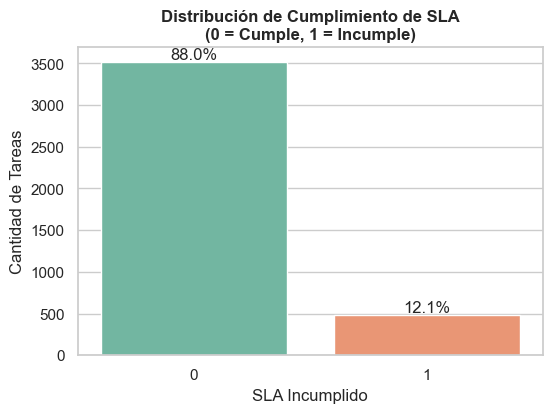

In [7]:
# Configurar el estilo general de los gráficos
sns.set_theme(style="whitegrid")

# --- Gráfico 1: Balance de la Variable Objetivo ---
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='sla_breached', palette='Set2')
plt.title('Distribución de Cumplimiento de SLA\n(0 = Cumple, 1 = Incumple)', fontsize=12, fontweight='bold')
plt.xlabel('SLA Incumplido')
plt.ylabel('Cantidad de Tareas')

# Añadir porcentajes sobre las barras
total = len(df)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(porcentaje, (x, y), ha='center', va='bottom')
    
plt.show()

C:\Users\PC RST\AppData\Local\Temp\ipykernel_17956\4209780166.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_limpio, x='priority', ax=axes[0], palette='viridis')
C:\Users\PC RST\AppData\Local\Temp\ipykernel_17956\4209780166.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_limpio, x='complexity', ax=axes[1], palette='magma')


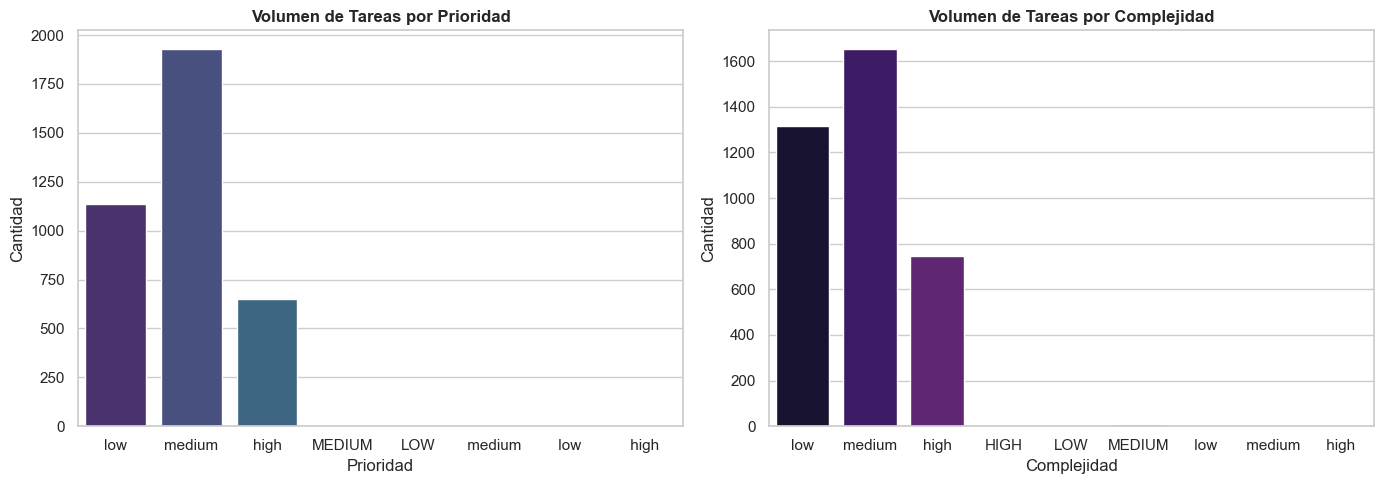

In [8]:
# --- Gráfico 2: Distribución del Volumen de Trabajo ---
# Creamos una figura con dos subgráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_limpio, x='priority', ax=axes[0], palette='viridis')
axes[0].set_title('Volumen de Tareas por Prioridad', fontweight='bold')
axes[0].set_xlabel('Prioridad')
axes[0].set_ylabel('Cantidad')

sns.countplot(data=df_limpio, x='complexity', ax=axes[1], palette='magma')
axes[1].set_title('Volumen de Tareas por Complejidad', fontweight='bold')
axes[1].set_xlabel('Complejidad')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

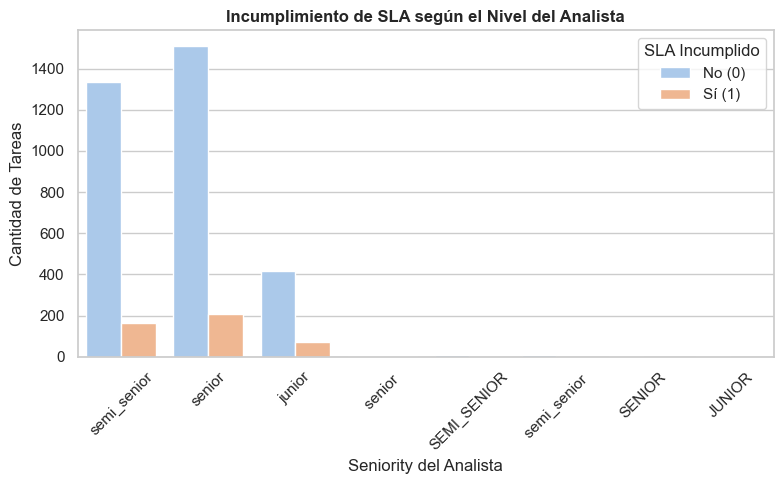

In [9]:
# --- Gráfico 3: Impacto del Seniority en el SLA ---
plt.figure(figsize=(8, 5))
sns.countplot(data=df_limpio, x='analyst_seniority', hue='sla_breached', palette='pastel')
plt.title('Incumplimiento de SLA según el Nivel del Analista', fontsize=12, fontweight='bold')
plt.xlabel('Seniority del Analista')
plt.ylabel('Cantidad de Tareas')
plt.legend(title='SLA Incumplido', labels=['No (0)', 'Sí (1)'])
plt.xticks(rotation=45) # Rotar los nombres por si son largos
plt.tight_layout()
plt.show()

In [10]:
# Imputación de valores Nulos (NaN) con la moda
# Pandas devuelve una Serie al calcular la moda, por lo que usamos [0] para extraer el valor en sí.

moda_complexity = df_limpio['complexity'].mode()[0]
moda_criticality = df_limpio['client_criticality'].mode()[0]

df_limpio['complexity'] = df_limpio['complexity'].fillna(moda_complexity)
df_limpio['client_criticality'] = df_limpio['client_criticality'].fillna(moda_criticality)

# Verificación de control de calidad para asegurarnos de que ya no hay nulos
print("\n--- Verificación post-imputación ---")
print(f"Nulos en complexity: {df_limpio['complexity'].isna().sum()}")
print(f"Nulos en client_criticality: {df_limpio['client_criticality'].isna().sum()}")

# --- Ahora sí es seguro aplicar pd.get_dummies() ---
df_preparado = pd.get_dummies(df_limpio, columns=columnas_categoricas, drop_first=True)


--- Verificación post-imputación ---
Nulos en complexity: 0
Nulos en client_criticality: 0


In [11]:
# Separar características (X) y etiqueta (y). Además, inicializamos nuestros datos de entrenamiento y prueba.
X = df_preparado.drop(columns=['sla_breached'])
y = df_preparado['sla_breached']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Estandarización (escalado de datos). Esto es para evitar que que el modelo le de mas peso a características con valores más altos en relación a otras.
escalador = StandardScaler()
X_train_escalado = escalador.fit_transform(X_train)
X_test_escalado = escalador.transform(X_test)

In [12]:
# BALANCEO CON SMOTE
# ==========================================

# Aplicamos SMOTE solo a los datos de entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_escalado, y_train)

# Comparamos el efecto de aplicar SMOTE  
print(f"Antes de SMOTE: {y_train.value_counts().to_dict()}")
print(f"Después de SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")

Antes de SMOTE: {0: 2299, 1: 316}
Después de SMOTE: {0: 2299, 1: 2299}


In [13]:
# ENTRENAMIENTO DEL MODELO
# ==========================================

# Entrenamos la regresión logística con los datos balanceados. Además, calculamos las predicciones sobre el set de prueba 
# que esta desbalanceado porque no le aplicamos SMOTE
modelo_log = LogisticRegression(random_state=42)
modelo_log.fit(X_train_res, y_train_res)
y_pred = modelo_log.predict(X_test_escalado)
print("\n--- Reporte de Clasificación de Regresión Logística con SMOTE ---")
print(classification_report(y_test, y_pred))


--- Reporte de Clasificación de Regresión Logística con SMOTE ---
              precision    recall  f1-score   support

           0       0.94      0.69      0.80       987
           1       0.23      0.69      0.35       135

    accuracy                           0.69      1122
   macro avg       0.59      0.69      0.57      1122
weighted avg       0.86      0.69      0.74      1122



In [14]:
# MODELO FINAL (RANDOM FOREST)
# ==========================================

# Definimos la cuadrícula de parámetros (grid) para aplicar un tuning simple e inicializamos el random forest base configurando con GridSearchCV
parametros_rf = { 'max_depth': [5, 10, 20, None], 'min_samples_leaf': [5, 10, 15, 20], 'n_estimators': [50, 100, 150, 200] }
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

busqueda = GridSearchCV(
    estimator=rf_base, 
    param_grid=parametros_rf, 
    scoring='f1', # Aca usamos la métrica f1 para maximizar el equilibrio entre precisión y recall
    cv=5, 
    n_jobs=-1
)

# Entrenamiento con validación cruzada usando los datos balanceados (reciclados del modelo de regresión logística) para obtener el mejor modelo balanceado
print("Iniciando búsqueda de hiperparámetros...")
busqueda.fit(X_train_res, y_train_res)
modelo_rf_perfecto = busqueda.best_estimator_
print(f"Mejores parámetros: {busqueda.best_params_}")

# Definir los costos del negocio (el criterio de la empresa)
COSTO_FP = 25   # Costo por falsa alarma (tiempo del analista)
COSTO_FN = 500  # Costo por fallo de SLA (multa o pérdida de cliente)

# Obtenemos las probabilidades crudas e iteramos para encontrar el umbral que minimiza la pérdida total
probs_test = modelo_rf_perfecto.predict_proba(X_test_escalado)[:, 1]

umbrales_a_probar = np.arange(0.25, 0.51, 0.01)
mejor_umbral = 0.5
minima_perdida = float('inf')
mejor_y_pred = None

print("Analizando impacto financiero por umbral...")

for u in umbrales_a_probar:
    y_pred_u = (probs_test >= u).astype(int)
    cm = confusion_matrix(y_test, y_pred_u)
    
    # Extraer errores: cm = [[TN, FP], [FN, TP]]
    fp = cm[0, 1]
    fn = cm[1, 0]
    
    # Función de impacto: Loss = (FP * C_fp) + (FN * C_fn)
    perdida_total = (fp * COSTO_FP) + (fn * COSTO_FN)
    
    if perdida_total < minima_perdida:
        minima_perdida = perdida_total
        mejor_umbral = u
        mejor_y_pred = y_pred_u

# Resultados del umbral económico
print(f"\n==================================================")
print(f"UMBRAL ECONÓMICO ÓPTIMO: {mejor_umbral:.2f}")
print(f"PÉRDIDA MÍNIMA ESTIMADA: ${minima_perdida:,}")
print(f"==================================================")
print(f"\n--- Reporte Final de Clasificación RF con Umbral Económico ---")
print(classification_report(y_test, mejor_y_pred))
print("\n--- Matriz de Confusión Final ---")
final_cm = confusion_matrix(y_test, mejor_y_pred)
print(final_cm)
# ROC-AUC (global del modelo)
print(f"\nROC-AUC Score global: {roc_auc_score(y_test, probs_test):.4f}")

Iniciando búsqueda de hiperparámetros...
Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 150}
Analizando impacto financiero por umbral...

UMBRAL ECONÓMICO ÓPTIMO: 0.25
PÉRDIDA MÍNIMA ESTIMADA: $28,475

--- Reporte Final de Clasificación RF con Umbral Económico ---
              precision    recall  f1-score   support

           0       0.94      0.64      0.76       987
           1       0.21      0.71      0.33       135

    accuracy                           0.65      1122
   macro avg       0.58      0.67      0.54      1122
weighted avg       0.85      0.65      0.71      1122


--- Matriz de Confusión Final ---
[[628 359]
 [ 39  96]]

ROC-AUC Score global: 0.7572
